In [ ]:
# 0 - data exploration

# The purpose of this notebook is to fix the model pipeline structure so that it
# uses a portion of the real paint to fit the calibration curve, and then
# we use the rest of the real paint to test the model. This will give us a better
# idea of how the model will actually perform. 

# note: after this notebook model performed worse. We didnt end up using the calibration curve anyway in the end.

In [2]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.data import load_images_from_metadata, filter_images

In [3]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to ../data\metadata.csv
Combined records: 1345


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1340,5.8,Brooke,7.21.26,TEST,2BDR-9F02,25-143,flat,../data_test\{leveling-5.8}_P{Brooke}_D{7.21.2...
1341,6.3,Brooke,7.21.26,TEST,2BDR-9F02,25-141,flat,../data_test\{leveling-6.3}_P{Brooke}_D{7.21.2...
1342,6.8,Brooke,7.21.26,TEST,2BDR-9F02,25-104,flat,../data_test\{leveling-6.8}_P{Brooke}_D{7.21.2...
1343,8.0,Brooke,7.21.26,TEST,2BDR-9F02,25-125,flat,../data_test\{leveling-8.0}_P{Brooke}_D{7.21.2...


In [4]:
# get the data
data = load_images_from_metadata("../data/metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

Loaded 1345 images (cropping=ON, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 1.5993
Epoch 4/10 - Loss: 3.2054
Epoch 6/10 - Loss: 1.9385
Epoch 8/10 - Loss: 4.5479
Epoch 10/10 - Loss: 1.1842

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.086203*Prediction^2 + -0.073869*Prediction + 1.964173

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.667
Within ±1: 78.8%
Within ±2: 97.0%
Within ±3: 99.5%
Within ±4: 100.0%


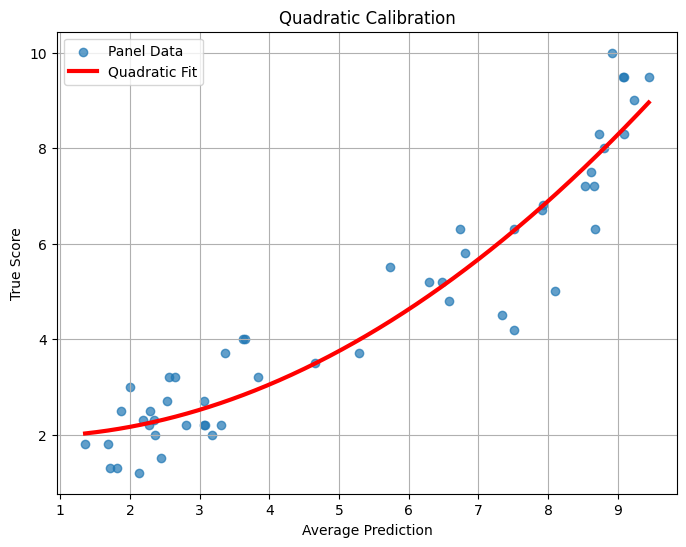

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-133       7.338823       0.845228        4.5  6
 25-113       1.864085       0.716663        2.5  6
 25-115       6.482245       0.707912        5.2 12
 25-145       7.513264       0.707369        4.2 12
 25-132       7.916840       0.678218        6.7 11
 25-126       2.528191       0.612619        2.7  6
 25-144       6.289863       0.602570        5.2 12
 25-110       3.625824       0.567465        4.0 12
 25-116       5.291667       0.546769        3.7  6
 25-150       8.107303       0.533294        5.0  6
 25-119       3.653702       0.506209        4.0  6
 25-101       3.075001       0.495384        2.2 11
 25-143       6.815525       0.493848        5.8  6
 25-136       6.739743       0.491167        6.3 12
 25-142       3.842960       0.408533        3.2 12
 25-109       2.188287       0.373960        2.3  6
 25-131       5.734819       0.366801        5.5  6
 25-120       2.562217       0.359755        3.2 12
 25-141     

In [6]:
# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (64,64)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

In [ ]:
#
# now lets try using only part of the real paint for the curve and the rest to test it
# so I want unique panels for the calibration and test
#

Training dataset: 177 standard images (NOT using real paint)
Real paint dataset (before panel split): 430 images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 1.5993
Epoch 4/10 - Loss: 3.2054
Epoch 6/10 - Loss: 1.9385
Epoch 8/10 - Loss: 4.5479
Epoch 10/10 - Loss: 1.1842

Training complete!

INFERRING ON ALL REAL PAINT IMAGES
Real paint data: 430 images
Predictions shape: (430,)

Panel split summary
  Total unique panels: 52
  Calibration panels: 26
  Holdout test panels: 26
  Calibration images: 192
  Holdout test images: 238

Quadratic Calibration Function (fit on calibration panels only)
TrueScore = 0.126507*Prediction^2 + -0.527151*Prediction + 3.118726

HOLDOUT TEST PERFORMANCE (PANELS NOT USED FOR CALIBRATION)
MAE: 0.837
Within +/-1: 64.7%
Within +/-2: 94.1%
Within +/-3: 97.9%
Within +/-4: 100.0%


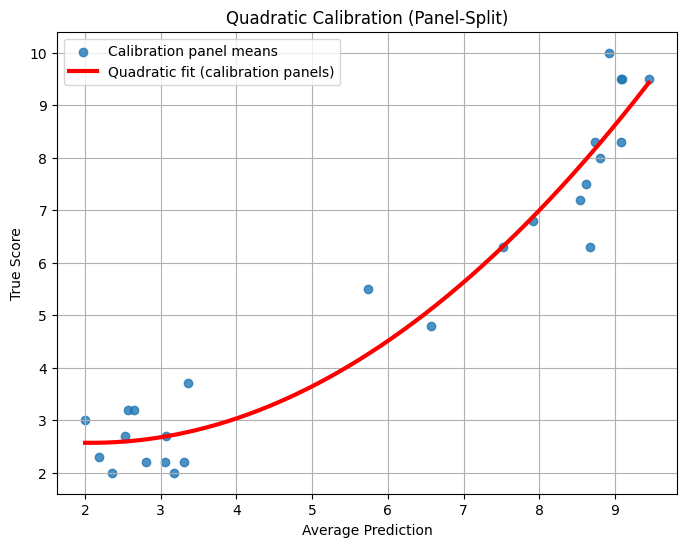


Holdout panel stats:
PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-133       7.338823       0.845228        4.5  6
 25-113       1.864085       0.716663        2.5  6
 25-115       6.482245       0.707912        5.2 12
 25-145       7.513264       0.707369        4.2 12
 25-132       7.916840       0.678218        6.7 11
 25-144       6.289863       0.602570        5.2 12
 25-110       3.625824       0.567465        4.0 12
 25-116       5.291667       0.546769        3.7  6
 25-150       8.107303       0.533294        5.0  6
 25-119       3.653702       0.506209        4.0  6
 25-101       3.075001       0.495384        2.2 11
 25-143       6.815525       0.493848        5.8  6
 25-136       6.739743       0.491167        6.3 12
 25-142       3.842960       0.408533        3.2 12
 25-108       2.124132       0.344735        1.2 12
 25-114       2.449296       0.329835        1.5  6
 25-111       1.814202       0.322918        1.3 12
 25-122       2.343897       0.315803     

In [ ]:
# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (64,64)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Real paint dataset (before panel split): {len(X_test_list)} images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT (for splitting)
# =========================
print("\n" + "="*60)
print("INFERRING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Real paint data: {len(X_test_list)} images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ BUILD RESULTS + PANEL SPLIT
# =========================
results_df = pd.DataFrame({
    "PanelID": groups_test,
    "Prediction": preds,
    "TrueLabel": y_test
})

# Keep only rows with a PanelID for group-safe split
results_df = results_df[results_df["PanelID"].notna()].copy()

# Split by unique PanelID
calibration_fraction = 0.5  # adjust as needed
rng = np.random.default_rng(42)
unique_panels = np.array(sorted(results_df["PanelID"].astype(str).unique()))
rng.shuffle(unique_panels)

n_cal_panels = max(1, int(round(len(unique_panels) * calibration_fraction)))
n_cal_panels = min(n_cal_panels, len(unique_panels) - 1) if len(unique_panels) > 1 else 1

cal_panels = set(unique_panels[:n_cal_panels])
test_panels = set(unique_panels[n_cal_panels:])

cal_df = results_df[results_df["PanelID"].astype(str).isin(cal_panels)].copy()
holdout_df = results_df[results_df["PanelID"].astype(str).isin(test_panels)].copy()

print("\nPanel split summary")
print(f"  Total unique panels: {len(unique_panels)}")
print(f"  Calibration panels: {len(cal_panels)}")
print(f"  Holdout test panels: {len(test_panels)}")
print(f"  Calibration images: {len(cal_df)}")
print(f"  Holdout test images: {len(holdout_df)}")

if len(cal_df) == 0 or len(holdout_df) == 0:
    raise RuntimeError("Panel split failed. Try adjusting calibration_fraction.")

# =========================
# ✅ FIT QUADRATIC ON CALIBRATION PANELS ONLY
# =========================
panel_summary_cal = (
    cal_df
    .groupby("PanelID", dropna=False)
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
    .reset_index()
)

x = panel_summary_cal["AvgPrediction"].values
y = panel_summary_cal["AvgTrueLabel"].values

if len(x) < 3 or len(np.unique(x)) < 3:
    raise RuntimeError("Not enough distinct calibration panel points to fit a quadratic curve.")

quad_coeffs = np.polyfit(x, y, 2)
a, b, c = quad_coeffs

print("\nQuadratic Calibration Function (fit on calibration panels only)")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

# Apply curve to holdout set only
holdout_df["QuadraticPrediction"] = (
    a * holdout_df["Prediction"]**2
    + b * holdout_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    holdout_df["TrueLabel"]
    - holdout_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)
w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("HOLDOUT TEST PERFORMANCE (PANELS NOT USED FOR CALIBRATION)")
print("="*60)
print(f"MAE: {mae_quad:.3f}")
print(f"Within +/-1: {w1_quad:.1f}%")
print(f"Within +/-2: {w2_quad:.1f}%")
print(f"Within +/-3: {w3_quad:.1f}%")
print(f"Within +/-4: {w4_quad:.1f}%")

# =========================
# ✅ CALIBRATION CURVE GRAPH (kept)
# =========================
xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.8, label="Calibration panel means")
plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic fit (calibration panels)"
    )
plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration (Panel-Split)")
plt.legend()
plt.grid(True)
plt.show()

# Optional diagnostics: holdout panel-level spread
panel_stats_holdout = (
    holdout_df
    .groupby("PanelID", dropna=False)
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print("\nHoldout panel stats:")
print(panel_stats_holdout.to_string(index=False))


# report the c-index and 